In [32]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [33]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [34]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [35]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth
    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [36]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent
        return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [37]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}
class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return state == self.goal
        # Return True if state is equal to the goal state.
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        legal_actions = []
        row,col= state
        for action,(dr,dc) in MOVES.items():
            next_row,next_col = row+dr,col+dc
            next_state=(next_row,next_col)

            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)

        # Return a list of legal action names.
        return legal_actions

        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row,col = state
        dr,dc = MOVES[action]
        return (row+dr,col+dc)

        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1

        raise NotImplementedError("Complete GridProblem.action_cost")
print("GridProblem class defined")

GridProblem class defined


5.1 Self-Check for GridProblem

In [38]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


6. Sample Drone Map

In [39]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

7. Visualisation Helper

In [40]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

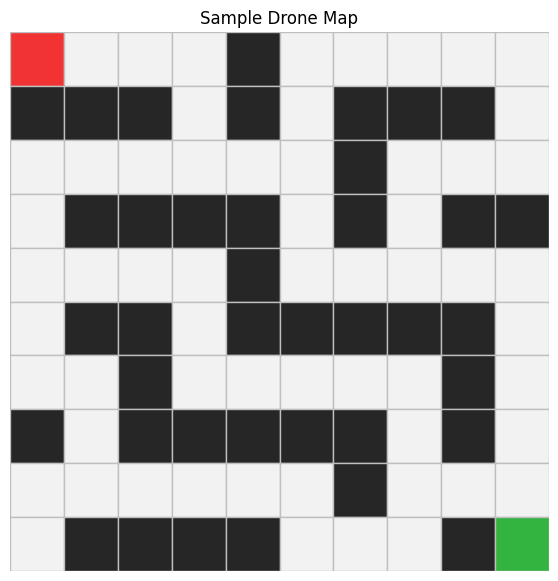

In [41]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

8. The Shared expand Method

In [42]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
      state=node.state
      for action in problem.actions(state):
        next_state=problem.result(state,action)
        cost=node.path_cost+problem.action_cost(state,action,next_state)
        yield Node(
            state=next_state,
            parent=node,
            action=action,
            path_cost=cost
            )


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass
print("SearchAlgorithm class defined")

SearchAlgorithm class defined


9. Breadth-First Search (BFS)

In [43]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        initial_node=Node(problem.initial_state())
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="SUCCESS",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
                )

        frontier = deque([initial_node])
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node=frontier.popleft()
            nodes_expanded+=1
            for child in self.expand(problem,node):
              state=child.state
              if problem.is_goal(state):
                return SearchResult(
                    algorithm=algorithm,
                    status="SUCCESS",
                    solution=child,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached) + 1
                )
              if state not in reached:
                frontier.append(child)
                reached.add(state)
                max_frontier_size=max(max_frontier_size,len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="FAILURE",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )



print("BreadthFirstSearch class defined")

BreadthFirstSearch class defined


10. Depth-First Search (DFS)

In [44]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        initial_node = Node(problem.initial_state())
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="SUCCESS",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )
        frontier = [initial_node]
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier_size = 1
        while frontier:
            node = frontier.pop()
            nodes_expanded += 1
            for child in self.expand(problem, node):
                state = child.state
                if problem.is_goal(state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="SUCCESS",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached) + 1,
                    )
                if state not in reached:
                    frontier.append(child)
                    reached.add(state)
                    max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(
            algorithm=algorithm,
            status="FAILURE",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )



print("DFS class defined")

DFS class defined


11. Depth-Limited Search (DLS)

In [45]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )
    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        # TODO 8:
        if problem.is_goal(node.state):
          return(node,"success")
        if node.depth >= limit:
          return(None,"cutoff")

        metrics["nodes_expanded"]+=1
        cutoff_occurred=False
        for child in self.expand(problem,node):
            if state_is_on_path(node,child.state):
                    continue
            new_stack_size = current_stack_size + 1
            if new_stack_size > metrics["max_stack_size"]:
                metrics["max_stack_size"] = new_stack_size
            result,status=self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=new_stack_size
                )
            if status == "success":
              return(result,"success")
            elif status == "cutoff":
              cutoff_occurred = True
        if cutoff_occurred:
          return(None,"cutoff")
        else:
          return(None,"failure")
print("DLS class defined")

DLS class defined


12. Iterative Deepening Search (IDS)

In [46]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        total_nodes_expanded = 0
        max_frontier_size_overall = 1

        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            total_nodes_expanded += result.nodes_expanded
            if result.max_frontier_size > max_frontier_size_overall:
                max_frontier_size_overall = result.max_frontier_size

            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "solution_depth": result.solution.depth
                if result.solution
                else
                None
            })

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="SUCCESS",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_frontier_size_overall,
                    reached_count=0,
                    iterations=iteration_log
                )
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="FAILURE",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_frontier_size_overall,
                    reached_count=0,
                    iterations=iteration_log
                )

        if result.status == "cutoff":
            return SearchResult(
                algorithm=algorithm,
                status="cutoff",
                solution=None,
                nodes_expanded=total_nodes_expanded,
                max_frontier_size=max_frontier_size_overall,
                reached_count=0,
                iterations=iteration_log,
                limit=max_depth
            )
        else:
            return SearchResult(
                algorithm=algorithm,
                status="FAILURE",
                solution=None,
                nodes_expanded=total_nodes_expanded,
                max_frontier_size=max_frontier_size_overall,
                reached_count=0,
                iterations=iteration_log,
                limit=max_depth
            )

print("IDS class defined")

IDS class defined


13. Run the Algorithms on the Sample Map

In [47]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

print("Sample map created!")

Sample map created!


In [48]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

print("Sample map created!")



Sample map created!


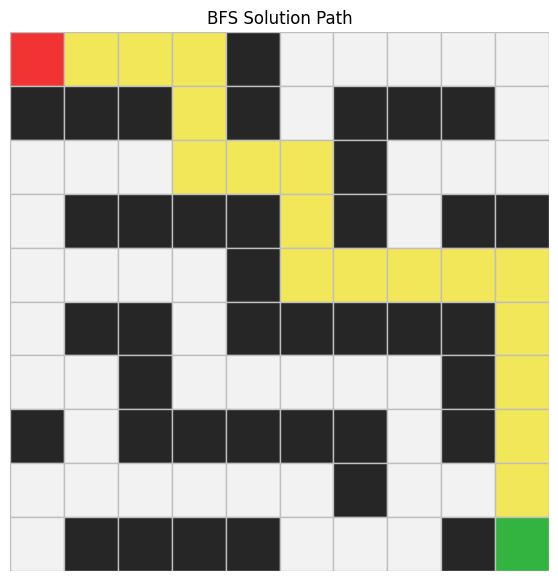

In [52]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

plot_path(
    sample_grid,
    start,
    goal,
    path=results[0].path,
    title="BFS Solution Path",
)


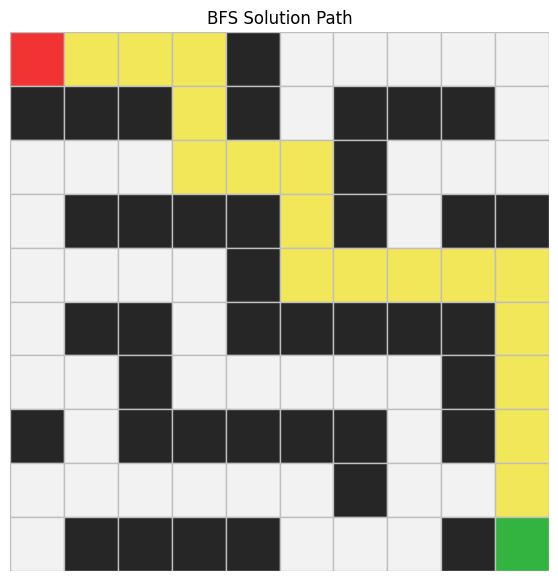

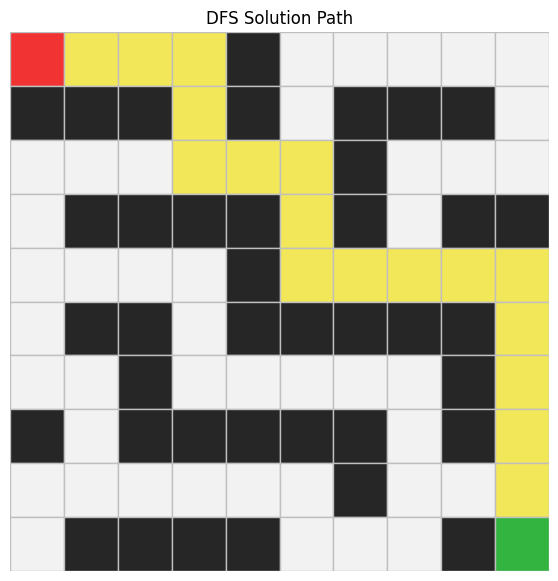

In [50]:

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)


14. Create Your Own Maps

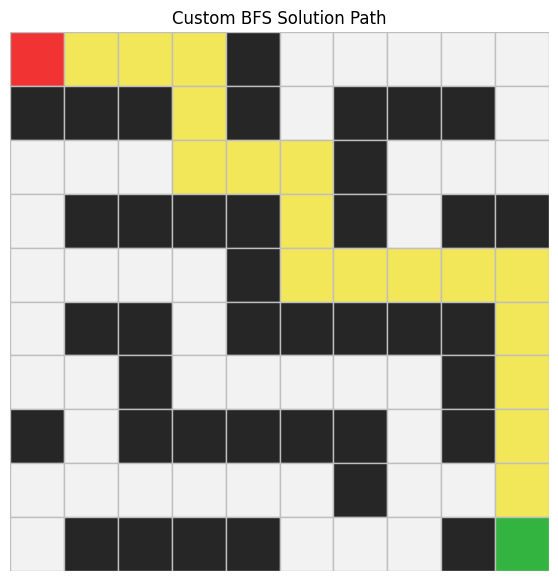

In [51]:

# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
   [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
   [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
   [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
   [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
   [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
   [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
   [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
   [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
   [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
   [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
bfs.search(custom_problem_1),
dfs.search(custom_problem_1),
dls.search(custom_problem_1, limit=20),
ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="Custom BFS Solution Path",
)

In [ ]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0,1,0,0,0,0,0,0,0,0],
    [0,1,0,1,1,1,1,1,1,0],
    [0,1,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,0,1,0],
    [0,1,1,1,1,1,1,0,1,0],
    [0,0,0,0,0,0,1,0,1,0],
    [0,1,1,1,1,0,1,0,1,0],
    [0,0,0,0,1,0,0,0,1,0],
    [0,1,1,0,1,1,1,1,1,0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (9, 9)


custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
bfs.search(custom_problem_2),
dfs.search(custom_problem_2),
dls.search(custom_problem_2, limit=20),
ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    title="Custom Map2 BFS Solution Path",
)


**15. Reflection** **Questions**

15.1 Problem Formulation
1.   A state is a position on the grid, represented as (row, col).
2. An action is the movement direction: UP, DOWN, LEFT, RIGHT.
3. It returns the next state after applying an action to the current state.
4.	It allows the same search algorithm to work on different problems (grid, puzzles, games) without modification.


15.2 BFS


**1**.BFS uses a FIFO queue to explore nodes in order of increasing depth (level by level).


**2**.BFS finds the shortest path in terms of number of steps on the unweighted grid, because it explores all nodes at depth d before depth d+1.


**3.** The role reached set play in BFS to prevent revisiting states, making it a graph search rather than a tree search.






15.3	DFS

**1.**	DFS uses a stack to explore the deepest node first (LIFO behavior).

**2.**	No, DFS is not guaranteed to find the shortest path because it may find a longer path before exploring shorter alternatives.

**3.**	DFS uses less memory than BFS. When the solution is deep and the branching factor is high, DFS stores fewer nodes.

**4.**	DFS performs badly when the search space has cycles (risk of infinite loops) or when the solution is shallow, but DFS explores deep dead-ends first.



15.4	DLS

1.	When the depth limit is too small, the algorithm returns "cutoff" without finding a solution.

2.	The meaning of "cutoff" is that the search reached the depth limit before finding a solution or exhausting all possibilities.

3.	DLS stops at a maximum depth, preventing infinite search.

4.	We use path-cycle checking in DLS to prevent infinite loops without using the global reached set (which would defeat the depth-limited purpose).



15.5	IDS

1.	IDS repeats DLS with increasing limits to combine BFS completeness with DFS memory efficiency.

2.	IDS is complete even though DLS with a small limit is not, because IDS eventually reaches the solution depth, at which point DLS finds it.

3.	 IDS use less memory than BFS because It uses DFS's memory O(depth) rather than BFS's O(branching depth).

4.	The cost of repeatedly searching from the root is the Time overhead - nodes at shallow depths are expanded multiple times.



15.6	Real-World Drone Context

1.	In a real drone application, what might make one route safer or more practical than another is avoiding areas with risk of collision, avoiding populated areas, and battery constraints.

2.	BFS, because it guarantees the shortest path in unweighted grids.

3.	DLS, because it allows you to restrict the maximum number of moves.

4.	Real drones navigate in 3D, have wind, battery constraints, dynamic obstacles, and continuous coordinates.
